In [11]:
import sys
from pathlib import Path

import json

import numpy as np
import h5py
import hdf5plugin 
import numba
from numba import prange

import matplotlib.pyplot as plt

import darling
import disell

In [2]:
RAW_BASE = Path(
    "/dtu/3d-imaging-center/projects/2022_QIM_PMP/raw_data_extern/"
    "2025_11_beamtime/id03/20251117/PROCESSED_DATA/"
    "red_dot/cells/grain_149_2p5pct__bin2_10x_20_layer_mosa"
)

h5_path = RAW_BASE / "red_dot_grain_149_2p5pct__bin2_10x_20_layer_mosa.h5"

In [3]:
def numeric_key(x):
    """Sort scan names such as '2.1', '10.1', '19.1' numerically."""
    try:
        return float(x)
    except ValueError:
        return x


def load_maxima_group(g):
    """Load orientation, KAM, RGB map, colour key and motor grid from one maxima group."""
    out = {}

    # Main maps
    out["mean_motor1"] = g["mean_motor1"][()]
    out["mean_motor2"] = g["mean_motor2"][()]
    out["mosa_m"] = np.stack(
        [out["mean_motor1"], out["mean_motor2"]],
        axis=-1,
    )

    # KAM
    out["kam_3x9"] = g["kam_3x9"][()]

    # Optional but usually useful
    for name in ["sum_intensity", "number_of_pixels", "max_pix_intensity"]:
        if name in g:
            out[name] = g[name][()]

    # RGB / colour-key products
    mosa = g["mosa"]
    out["rgbmap"] = mosa["rgbmap"][()]
    out["colorkey"] = mosa["colorkey"][()]
    out["colorgrid"] = mosa["colorgrid"][()]

    # Motor grid from colourgrid.
    # Expected shape from your H5 dump: (2, 512, 512)
    cg = out["colorgrid"]
    out["motor1_grid"] = cg[0]
    out["motor2_grid"] = cg[1]

    # 1D motor axes inferred from colourgrid
    out["motor1_axis"] = cg[0, 0, :]
    out["motor2_axis"] = cg[1, :, 0]

    return out



In [4]:

data = {}

with h5py.File(h5_path, "r") as f:
    for scan_name in sorted(f["scans"].keys(), key=numeric_key):
        scan_group = f[f"scans/{scan_name}"]
        data[scan_name] = {}

        for maxima_name in sorted(scan_group.keys()):
            if not maxima_name.startswith("maxima_"):
                continue

            data[scan_name][maxima_name] = load_maxima_group(scan_group[maxima_name])


print(f"Loaded file: {h5_path}")
print(f"Number of scans: {len(data)}")
print("Scans:", list(data.keys()))

first_scan = list(data.keys())[0]
print("Maxima in first scan:", list(data[first_scan].keys()))
print("Available fields:", list(data[first_scan]["maxima_0"].keys()))

Loaded file: /dtu/3d-imaging-center/projects/2022_QIM_PMP/raw_data_extern/2025_11_beamtime/id03/20251117/PROCESSED_DATA/red_dot/cells/grain_149_2p5pct__bin2_10x_20_layer_mosa/red_dot_grain_149_2p5pct__bin2_10x_20_layer_mosa.h5
Number of scans: 21
Scans: ['2.1', '3.1', '4.1', '5.1', '6.1', '7.1', '8.1', '9.1', '10.1', '11.1', '12.1', '13.1', '14.1', '15.1', '16.1', '17.1', '18.1', '19.1', '20.1', '21.1', '22.1']
Maxima in first scan: ['maxima_0', 'maxima_1', 'maxima_2']
Available fields: ['mean_motor1', 'mean_motor2', 'mosa_m', 'kam_3x9', 'sum_intensity', 'number_of_pixels', 'max_pix_intensity', 'rgbmap', 'colorkey', 'colorgrid', 'motor1_grid', 'motor2_grid', 'motor1_axis', 'motor2_axis']


In [7]:
CHANNELS = {
    "mean_motor1": 0,
    "mean_motor2": 1,
    "kam_3x9": 2,
    "sum_intensity": 3,
    "number_of_pixels": 4,
    "max_pix_intensity": 5,
}


def make_volume_from_data(data, maxima_name="maxima_0"):
    """Make a registered-ready 3D volume from one maxima group.

    The output volume has shape (Z, Y, X, C), with channels:

    0: mean_motor1
    1: mean_motor2
    2: kam_3x9
    3: sum_intensity
    4: number_of_pixels
    5: max_pix_intensity
    """
    scan_names = sorted(data.keys(), key=numeric_key)

    volume_layers = []
    rgb_layers = []

    for scan_name in scan_names:
        d = data[scan_name][maxima_name]

        layer = np.stack(
            [
                d["mean_motor1"],
                d["mean_motor2"],
                d["kam_3x9"],
                d["sum_intensity"],
                d["number_of_pixels"],
                d["max_pix_intensity"],
            ],
            axis=-1,
        ).astype(np.float32)

        volume_layers.append(layer)
        rgb_layers.append(d["rgbmap"].astype(np.float32))

    volume = np.stack(volume_layers, axis=0)
    rgb_volume = np.stack(rgb_layers, axis=0)

    first = data[scan_names[0]][maxima_name]

    colorkey = first["colorkey"]
    colorgrid = first["colorgrid"]
    motor1_grid = first["motor1_grid"]
    motor2_grid = first["motor2_grid"]
    motor1_axis = first["motor1_axis"]
    motor2_axis = first["motor2_axis"]

    # Conservative valid mask.
    mask = (
        np.isfinite(volume[..., CHANNELS["mean_motor1"]])
        & np.isfinite(volume[..., CHANNELS["mean_motor2"]])
        & np.isfinite(volume[..., CHANNELS["kam_3x9"]])
        & np.isfinite(volume[..., CHANNELS["sum_intensity"]])
        & (volume[..., CHANNELS["sum_intensity"]] > 0)
        & np.isfinite(volume[..., CHANNELS["number_of_pixels"]])
        & (volume[..., CHANNELS["number_of_pixels"]] > 0)
    )

    out = {
        "scan_names": scan_names,
        "maxima_name": maxima_name,
        "volume": np.ascontiguousarray(volume),
        "rgb_volume": np.ascontiguousarray(rgb_volume),
        "mask": np.ascontiguousarray(mask),
        "colorkey": colorkey,
        "colorgrid": colorgrid,
        "motor1_grid": motor1_grid,
        "motor2_grid": motor2_grid,
        "motor1_axis": motor1_axis,
        "motor2_axis": motor2_axis,
        "channels": CHANNELS,
    }

    return out

In [8]:
volumes = {}

for maxima_name in ["maxima_0"]:
    volumes[maxima_name] = make_volume_from_data(data, maxima_name=maxima_name)

    v = volumes[maxima_name]["volume"]
    rgb = volumes[maxima_name]["rgb_volume"]
    mask = volumes[maxima_name]["mask"]

    print("\n", maxima_name)
    print("volume:", v.shape)
    print("rgb_volume:", rgb.shape)
    print("mask:", mask.shape)
    print("valid fraction:", mask.mean())


 maxima_0
volume: (21, 338, 1022, 6)
rgb_volume: (21, 338, 1022, 3)
mask: (21, 338, 1022)
valid fraction: 0.4224222638719101


KeyError: 'kam_3   x9'

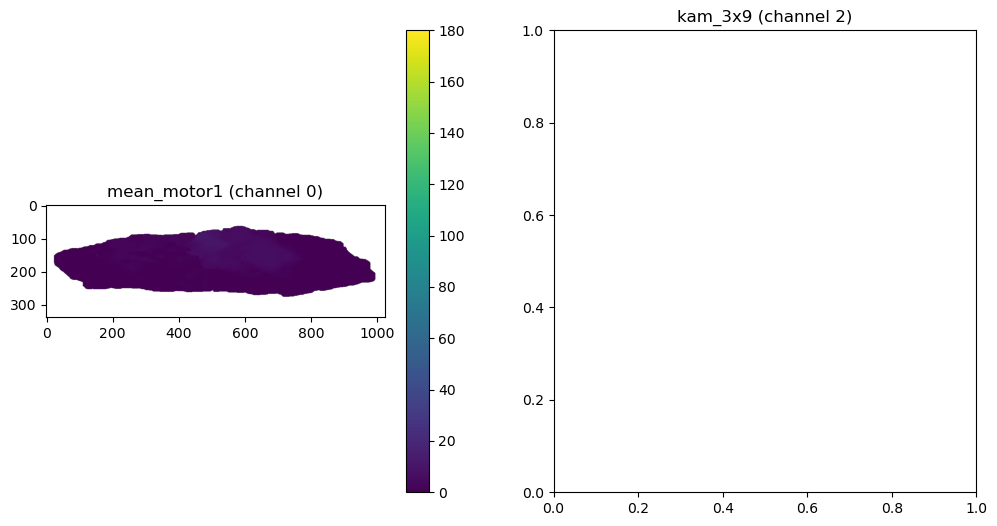

In [16]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("mean_motor1 (channel 0)")
plt.imshow(volumes["maxima_0"]["volume"][..., CHANNELS["mean_motor1"]][0])
plt.colorbar()
plt.subplot(1, 2, 2)
plt.title("kam_3x9 (channel 2)")
plt.imshow(volumes["maxima_0"]["volume"][..., CHANNELS["kam_3x9"]][0], vmin=0, vmax=0.5)
plt.colorbar()  


In [9]:
mx = "maxima_0"

volume = volumes[mx]["volume"]
rgb_volume = volumes[mx]["rgb_volume"]
mask = volumes[mx]["mask"]

mean_motor1_volume = volume[..., CHANNELS["mean_motor1"]]
mean_motor2_volume = volume[..., CHANNELS["mean_motor2"]]
kam_volume = volume[..., CHANNELS["kam_3x9"]]
sum_intensity_volume = volume[..., CHANNELS["sum_intensity"]]

seg_input = np.ascontiguousarray(volume[..., [0, 1]].astype(np.float32))

colorkey = volumes[mx]["colorkey"]
colorgrid = volumes[mx]["colorgrid"]
motor1_axis = volumes[mx]["motor1_axis"]
motor2_axis = volumes[mx]["motor2_axis"]

print("seg_input:", seg_input.shape)
print("kam_volume:", kam_volume.shape)
print("motor1 range:", np.nanmin(motor1_axis), np.nanmax(motor1_axis))
print("motor2 range:", np.nanmin(motor2_axis), np.nanmax(motor2_axis))

seg_input: (21, 338, 1022, 2)
kam_volume: (21, 338, 1022)
motor1 range: -20.943897247314453 -20.943897247314453
motor2 range: -17.015722274780273 -17.015722274780273


In [12]:


transforms = disell.register(
    volume,
    registration_channel=CHANNELS["sum_intensity"],
    verbose=True,
)

registered = disell.apply_transforms(
    volume,
    transforms,
    pad_value=np.nan,
)

rgb_registered = disell.apply_transforms(
    rgb_volume,
    transforms,
    pad_value=np.nan,
)

mask_registered_float = disell.apply_transforms(
    mask.astype(np.float32)[..., None],
    transforms,
    pad_value=0,
)[..., 0]

mask_registered = mask_registered_float > 0.5

print("registered:", registered.shape)
print("rgb_registered:", rgb_registered.shape)
print("mask_registered:", mask_registered.shape)

[0] Shift: [0. 0.]
[1] Shift: [0. 0.]
[2] Shift: [0. 0.]
[3] Shift: [0. 0.]
[4] Shift: [0. 0.]
[5] Shift: [0. 0.]
[6] Shift: [0. 0.]
[7] Shift: [0. 0.]
[8] Shift: [0. 0.]
[9] Shift: [0. 0.]
[11] Shift: [0. 0.]
[12] Shift: [0. 0.]
[13] Shift: [0. 0.]
[14] Shift: [0. 0.]
[15] Shift: [0. 0.]
[16] Shift: [0. 0.]
[17] Shift: [0. 0.]
[18] Shift: [0. 0.]
[19] Shift: [0. 0.]
[20] Shift: [0. 0.]
registered: (21, 338, 1022, 6)
rgb_registered: (21, 338, 1022, 3)
mask_registered: (21, 338, 1022)


In [ ]:
seg_input = np.ascontiguousarray(
    registered[..., [CHANNELS["mean_motor1"], CHANNELS["mean_motor2"]]]
)

kam_volume = np.ascontiguousarray(
    registered[..., CHANNELS["kam_3x9"]]
)

mask_bool = (
    mask_registered
    & np.isfinite(seg_input[..., 0])
    & np.isfinite(seg_input[..., 1])
    & np.isfinite(kam_volume)
    & np.isfinite(registered[..., CHANNELS["sum_intensity"]])
    & (registered[..., CHANNELS["sum_intensity"]] > 0)
)

mask_uint8 = np.ascontiguousarray(mask_bool.astype(np.uint8))

print("seg_input:", seg_input.shape)
print("kam_volume:", kam_volume.shape)
print("mask:", mask_uint8.shape)
print("valid voxels:", mask_uint8.sum())

seg_input: (21, 338, 1022, 2)
kam_volume: (21, 338, 1022)
mask: (21, 338, 1022)
valid voxels: 3039571


In [14]:
footprint = np.zeros((3, 3, 3), dtype=bool)

footprint[0, 1, :] = True
footprint[0, :, 1] = True
footprint[1, :, :] = True
footprint[2, 1, :] = True
footprint[2, :, 1] = True

result, sizes_initial = disell.flood_fill_dfxm_two_stage(
    seg_input,
    footprint=footprint,
    local_misorientation_threshold=0.01,
    global_threshold=0.5,
    footprint_tolerance=0.70,
    mask=mask_uint8,
    max_iterations=1_500_000,
    min_grain_size=5,
    recycle_small_grains=True,
    stagnation_tolerance=10_000,
)

markers = result["segmentation"].astype(np.int32)

print("markers:", markers.shape)
print("number of seed cells:", markers.max())
print("seed coverage:", np.count_nonzero(markers) / mask_bool.sum())

No valid seeds found — return empty segmentation
markers: (21, 338, 1022)
number of seed cells: 0
seed coverage: 0.0


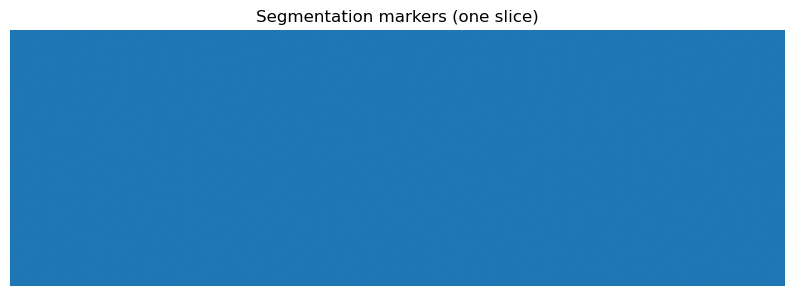

In [15]:
plt.figure(figsize=(10, 10))
plt.imshow(markers[markers.shape[0] // 2], cmap="tab20")
plt.title("Segmentation markers (one slice)")
plt.axis("off")
plt.show()

In [ ]:
kam_ws = kam_volume.copy()
kam_ws[~np.isfinite(kam_ws)] = np.nanpercentile(kam_ws[mask_bool], 99)

final_labels = disell.region_grow_watershed(
    seg=markers,
    mask=mask_bool,
    feature=kam_ws,
    connectivity=1,
).astype(np.int32)

print("final_labels:", final_labels.shape)
print("number of final cells:", final_labels.max())
print("final coverage:", np.count_nonzero(final_labels) / mask_bool.sum())

In [ ]:
from skimage.segmentation import find_boundaries

z = final_labels.shape[0] // 2

bd_markers = find_boundaries(markers[z], mode="outer")
bd_final = find_boundaries(final_labels[z], mode="outer")

fig, ax = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

ax[0].imshow(rgb_registered[z])
ax[0].set_title(f"{mx}, z={z}: registered RGB")

ax[1].imshow(rgb_registered[z])
ax[1].imshow(np.ma.masked_where(~bd_markers, bd_markers), cmap="gray", alpha=1)
ax[1].set_title("flood-fill markers")

ax[2].imshow(rgb_registered[z])
ax[2].imshow(np.ma.masked_where(~bd_final, bd_final), cmap="gray", alpha=1)
ax[2].set_title("watershed on KAM 3x9")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()